# Import Libraries

In [18]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
sns.set(style="whitegrid")

# Load Dataset

In [4]:
payments = pd.read_csv(r"C:\Users\urvas\Downloads\Customer segmentation\data/olist_order_payments_dataset.csv")
payments.head()

,order_id,payment_sequential,payment_type,payment_installments,payment_value
0,b81ef226f3fe1789b1e8b2acac839d17,1,credit_card,8,99.33
1,a9810da82917af2d9aefd1278f1dcfa0,1,credit_card,1,24.39
2,25e8ea4e93396b6fa0d3dd708e76c1bd,1,credit_card,1,65.71
3,ba78997921bbcdc1373bb41e913ab953,1,credit_card,8,107.78
4,42fdf880ba16b47b59251dd489d4441a,1,credit_card,2,128.45


# Data Cleaning and Preprocessing

In [5]:
payments.shape

(103886, 5)

In [6]:
payments.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 103886 entries, 0 to 103885
Data columns (total 5 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   order_id              103886 non-null  object 
 1   payment_sequential    103886 non-null  int64  
 2   payment_type          103886 non-null  object 
 3   payment_installments  103886 non-null  int64  
 4   payment_value         103886 non-null  float64
dtypes: float64(1), int64(2), object(2)
memory usage: 4.0+ MB


In [7]:
payments.describe()

,payment_sequential,payment_installments,payment_value
count,103886.000000,103886.000000,103886.000000
mean,1.092679,2.853349,154.100380
std,0.706584,2.687051,217.494064
min,1.000000,0.000000,0.000000
25%,1.000000,1.000000,56.790000
50%,1.000000,1.000000,100.000000
75%,1.000000,4.000000,171.837500
max,29.000000,24.000000,13664.080000


In [8]:
payments.isnull().sum()

order_id                0
payment_sequential      0
payment_type            0
payment_installments    0
payment_value           0
dtype: int64

# Payment Type Distribution

In [9]:
payment_counts = payments['payment_type'].value_counts()
payment_counts

payment_type
credit_card    76795
boleto         19784
voucher         5775
debit_card      1529
not_defined        3
Name: count, dtype: int64

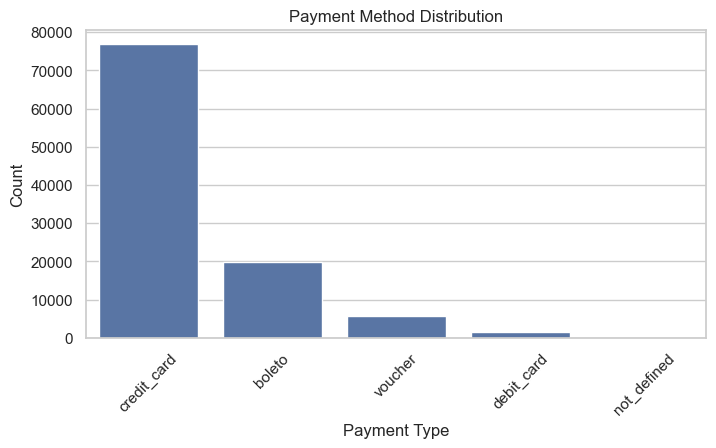

In [19]:
#Payment Methods
plt.figure(figsize=(8,4))
sns.barplot(x=payment_counts.index, y=payment_counts.values)
plt.title("Payment Method Distribution")
plt.xlabel("Payment Type")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.show()

# Installments Analysis

In [11]:
payments['payment_installments'].describe()

count    103886.000000
mean          2.853349
std           2.687051
min           0.000000
25%           1.000000
50%           1.000000
75%           4.000000
max          24.000000
Name: payment_installments, dtype: float64

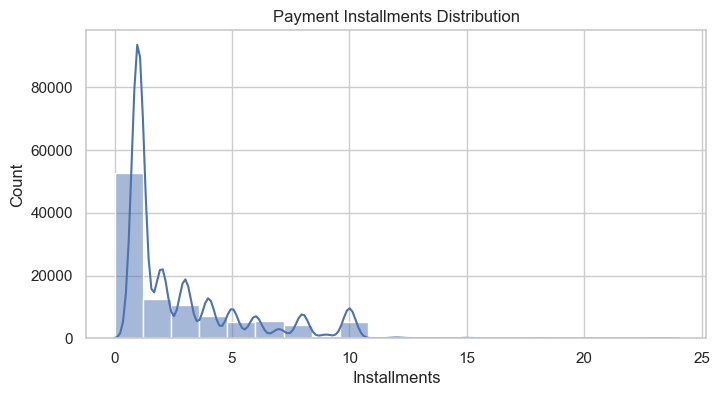

In [20]:
#Installments Distribution
plt.figure(figsize=(8,4))
sns.histplot(payments['payment_installments'], bins=20, kde=True)
plt.title("Payment Installments Distribution")
plt.xlabel("Installments")
plt.show()

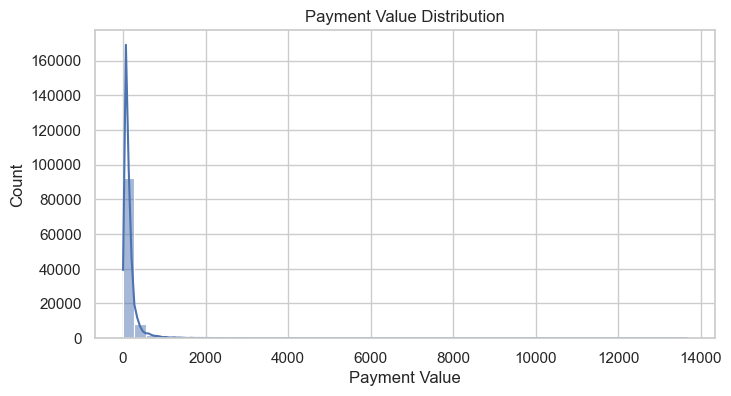

In [21]:
#Payment Value Distribution
plt.figure(figsize=(8,4))
sns.histplot(payments['payment_value'], bins=50, kde=True)
plt.title("Payment Value Distribution")
plt.xlabel("Payment Value")
plt.show()

# Multiple Payments per Order

In [14]:
payments_per_order = payments.groupby('order_id').size()
payments_per_order.describe()

count    99440.000000
mean         1.044710
std          0.381166
min          1.000000
25%          1.000000
50%          1.000000
75%          1.000000
max         29.000000
dtype: float64

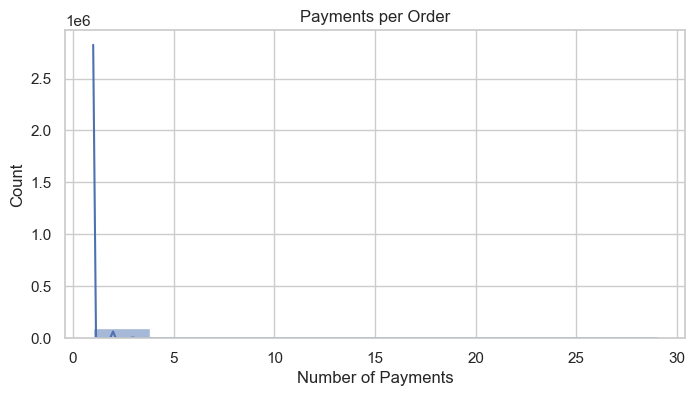

In [22]:
#Payments per Order
plt.figure(figsize=(8,4))
sns.histplot(payments_per_order, bins=10, kde=True)
plt.title("Payments per Order")
plt.xlabel("Number of Payments")
plt.show()

# Aggregate Payment Features per Order

In [16]:
payment_features = (
    payments.groupby('order_id')
    .agg(
        total_payment_value=('payment_value', 'sum'),
        max_installments=('payment_installments', 'max'),
        payment_types=('payment_type', lambda x: x.nunique())
    )
    .reset_index()
)

# Save Dataset- Payment

In [17]:
os.makedirs("processed", exist_ok=True)
payment_features.to_csv("processed/payments_clean.csv", index=False)